In [2]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [4]:
df=pd.read_csv('/content/mice_final_data.csv')
cols=df.columns
df

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_co2_deviation,stage4_o2_deviation,stage4_n_deviation,stage5_flow_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,label
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,-0.381981,-0.917519,2.905965,-0.914915,14.642069,-1.124235,2.249968,0.823538,1.574354,1
1,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,14.243738,-4.937284,0.089265,-4.937284,12.361204,3.886517,3.381750,5.827666,-0.056206,1
2,31.25,29.16,31.45,30.74,30.26,67.98,78.42,70.97,67.71,70.73,...,5.685728,-0.955917,0.871249,-0.955908,1.587669,1.665659,-0.052572,-0.597566,-2.745544,0
3,29.96,29.22,28.39,31.96,31.12,68.60,67.80,70.09,71.88,76.71,...,5.497906,-2.134062,-1.188985,-2.134062,4.550075,0.020477,3.230979,-0.032255,0.157905,0
4,30.09,29.58,28.06,30.46,28.84,78.24,67.31,72.63,77.78,74.76,...,7.259878,-0.192612,-1.648626,-0.192612,9.741397,0.979056,-0.516248,2.129390,0.020616,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16993,29.68,29.91,30.18,30.78,28.06,77.29,75.94,75.59,73.05,73.09,...,-6.240376,-1.627189,-0.384339,-1.627189,-1.251171,-0.972060,2.343462,-0.342200,1.252295,0
16994,30.24,28.95,28.87,28.94,29.23,76.02,71.39,68.73,70.77,69.52,...,-1.139003,2.228396,0.044608,2.228396,5.861357,0.414884,-1.108650,-0.813562,1.744824,1
16995,28.44,28.81,31.56,30.57,28.79,72.11,70.08,73.60,73.15,68.72,...,3.729189,-0.858941,0.124091,-0.859033,-0.722216,4.351513,0.000299,1.684467,-1.652202,0
16996,28.17,28.47,28.79,28.99,29.71,75.93,77.20,67.56,76.45,76.70,...,-1.567624,-2.373612,-0.820434,-2.373612,-5.930715,1.433596,-2.000998,4.125043,-0.552398,0


In [5]:
from sklearn.metrics import classification_report, confusion_matrix

def train_and_evaluate_S(model, model_name, X_train, y_train, X_test, y_test):

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    # 1️⃣ 모델 학습
    pipe.fit(X_train, y_train)

    # 2️⃣ 예측
    y_pred = pipe.predict(X_test)

    # 3️⃣ 평가 출력
    print(f"\n===== {model_name} 평가 결과 =====")

    print(classification_report(
        y_test,
        y_pred,
        target_names=['정상', '불량'],
        digits=4
    ))

    plt.figure(figsize=(7,4))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=labels,
                yticklabels=labels,
                annot_kws={"size":14})   # 숫자 크기

    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.title('Confusion Matrix', fontsize=16)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.show()

    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    return pipe, y_pred

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):


    # 1️⃣ 모델 학습
    model.fit(X_train, y_train)

    # 2️⃣ 예측
    y_pred = model.predict(X_test)

    # 3️⃣ 평가 출력
    print(f"\n===== {model_name} 평가 결과 =====")

    print(classification_report(
        y_test,
        y_pred,
        target_names=['정상', '불량'],
        digits=4
    ))

    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    cm= confusion_matrix(y_test, y_pred)
    labels = ['정상', '불량']

    # Heatmap
    plt.figure(figsize=(5,4))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=labels,
                yticklabels=labels,
                annot_kws={"size":14})   # 숫자 크기

    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.title('Confusion Matrix', fontsize=16)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.show()

    return model, y_pred

In [ ]:
from xgboost import XGBClassifier
x=df[cols[:40]]
y=df[cols[40]]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
xg_model = XGBClassifier(random_state=42)

model, y_pred_xg = train_and_evaluate(
    xg_model,
    "XGBoost",
    X_train,
    y_train,
    X_test,
    y_test
)


===== XGBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9592    0.9867    0.9727      2713
          불량     0.9409    0.8341    0.8843       687

    accuracy                         0.9559      3400
   macro avg     0.9500    0.9104    0.9285      3400
weighted avg     0.9555    0.9559    0.9549      3400

Confusion matrix:
 [[2677   36]
 [ 114  573]]


In [ ]:
x=df[cols[:40]]
y=df[cols[40]]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
LG_model = LGBMClassifier(random_state=42)

model, y_pred_xg = train_and_evaluate(
    LG_model,
    "LGBM",
    X_train,
    y_train,
    X_test,
    y_test
)

[LightGBM] [Info] Number of positive: 2750, number of negative: 10848
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024555 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10138
[LightGBM] [Info] Number of data points in the train set: 13598, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.202236 -> initscore=-1.372380
[LightGBM] [Info] Start training from score -1.372380

===== LGBM 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9524    0.9893    0.9705      2713
          불량     0.9502    0.8049    0.8716       687

    accuracy                         0.9521      3400
   macro avg     0.9513    0.8971    0.9210      3400
weighted avg     0.9520    0.9521    0.9505      3400

Confusion matrix:
 [[2684   29]
 [ 134  553]]


In [7]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.4 MB/s eta 0:00:00



===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9631    0.9923    0.9775      2713
          불량     0.9653    0.8501    0.9040       687

    accuracy                         0.9635      3400
   macro avg     0.9642    0.9212    0.9408      3400
weighted avg     0.9636    0.9635    0.9626      3400

Confusion matrix:
 [[2692   21]
 [ 103  584]]


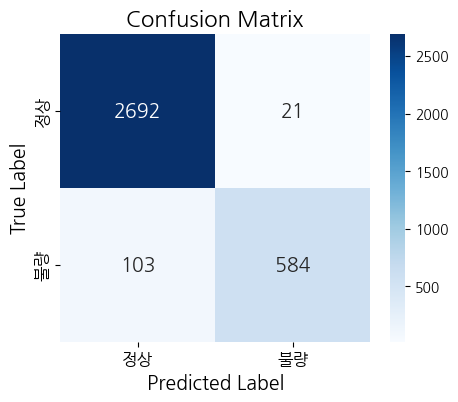

In [12]:
import koreanize_matplotlib

x=df[cols[:40]]
y=df[cols[40]]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
cat_model = CatBoostClassifier(random_state=42,verbose=0)

model, y_pred_xg = train_and_evaluate(
    cat_model,
    "CatBoost",
    X_train,
    y_train,
    X_test,
    y_test
)

In [ ]:
x=df[cols[:40]]
y=df[cols[40]]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
SVC_model = SVC(random_state=42)

model, y_pred_xg = train_and_evaluate_S(
    SVC_model,
    "SVC",
    X_train,
    y_train,
    X_test,
    y_test
)


===== SVC 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9628    0.9930    0.9777      2713
          불량     0.9684    0.8486    0.9046       687

    accuracy                         0.9638      3400
   macro avg     0.9656    0.9208    0.9411      3400
weighted avg     0.9640    0.9638    0.9629      3400

Confusion matrix:
 [[2694   19]
 [ 104  583]]


In [ ]:

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "SVM (Scaled)": SVC(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

results = []

for name, model in models.items():
    if "Scaled" in name:
        train_x, test_x = X_train_scaled, X_test_scaled
    else:
        train_x, test_x = X_train, X_test

    model.fit(train_x, y_train)
    y_pred = model.predict(test_x)

    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    print(f"{name} 완료")

results_df = pd.DataFrame(results)
print("\n모델 성능 비교")
print(results_df.to_string(index=False))

SVM (Scaled) 완료
[LightGBM] [Info] Number of positive: 2750, number of negative: 10848
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10138
[LightGBM] [Info] Number of data points in the train set: 13598, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.202236 -> initscore=-1.372380
[LightGBM] [Info] Start training from score -1.372380
LightGBM 완료
XGBoost 완료
CatBoost 완료

모델 성능 비교
       Model  Accuracy  Precision  Recall  F1-Score
SVM (Scaled)    0.9638     0.9684  0.8486    0.9046
    LightGBM    0.9521     0.9502  0.8049    0.8716
     XGBoost    0.9559     0.9409  0.8341    0.8843
    CatBoost    0.9638     0.9669  0.8501    0.9047


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "SVM (Scaled)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42))
    ]),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

results = []

for name, model in models.items():

    # 🔹 1️⃣ Cross Validation (train 데이터에서만)
    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',  # 불균형이면 f1 추천
        n_jobs=-1
    )

    cv_mean = round(cv_scores['test_score'].mean(), 4)

    # 🔹 2️⃣ 전체 train으로 재학습
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)

    results.append({
        "Model": name,
        "CV_F1 (5-fold)": cv_mean,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score (Test)": f1
    })

    print(f"{name} 완료")

results_df = pd.DataFrame(results)

print("\n모델 성능 비교")
print(results_df.to_string(index=False))

SVM (Scaled) 완료
[LightGBM] [Info] Number of positive: 2750, number of negative: 10848
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10138
[LightGBM] [Info] Number of data points in the train set: 13598, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.202236 -> initscore=-1.372380
[LightGBM] [Info] Start training from score -1.372380
LightGBM 완료
XGBoost 완료
CatBoost 완료

모델 성능 비교
       Model  CV_F1 (5-fold)  Accuracy  Precision  Recall  F1-Score (Test)
SVM (Scaled)          0.8988    0.9638     0.9684  0.8486           0.9046
    LightGBM          0.8697    0.9521     0.9502  0.8049           0.8716
     XGBoost          0.8726    0.9559     0.9409  0.8341           0.8843
    CatBoost          0.8960    0.9638     0.9669  0.8501           0.9047


In [ ]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

# 평가
acc = round(accuracy_score(y_test, y_pred), 4)
prec = round(precision_score(y_test, y_pred), 4)
rec = round(recall_score(y_test, y_pred), 4)
f1 = round(f1_score(y_test, y_pred), 4)

print("catboost 모델 성능")
print(f"Accuracy : {acc}")
print(f"Precision: {prec}")
print(f"Recall   : {rec}")
print(f"F1-score : {f1}")

catboost 모델 성능
Accuracy : 0.9638
Precision: 0.9669
Recall   : 0.8501
F1-score : 0.9047


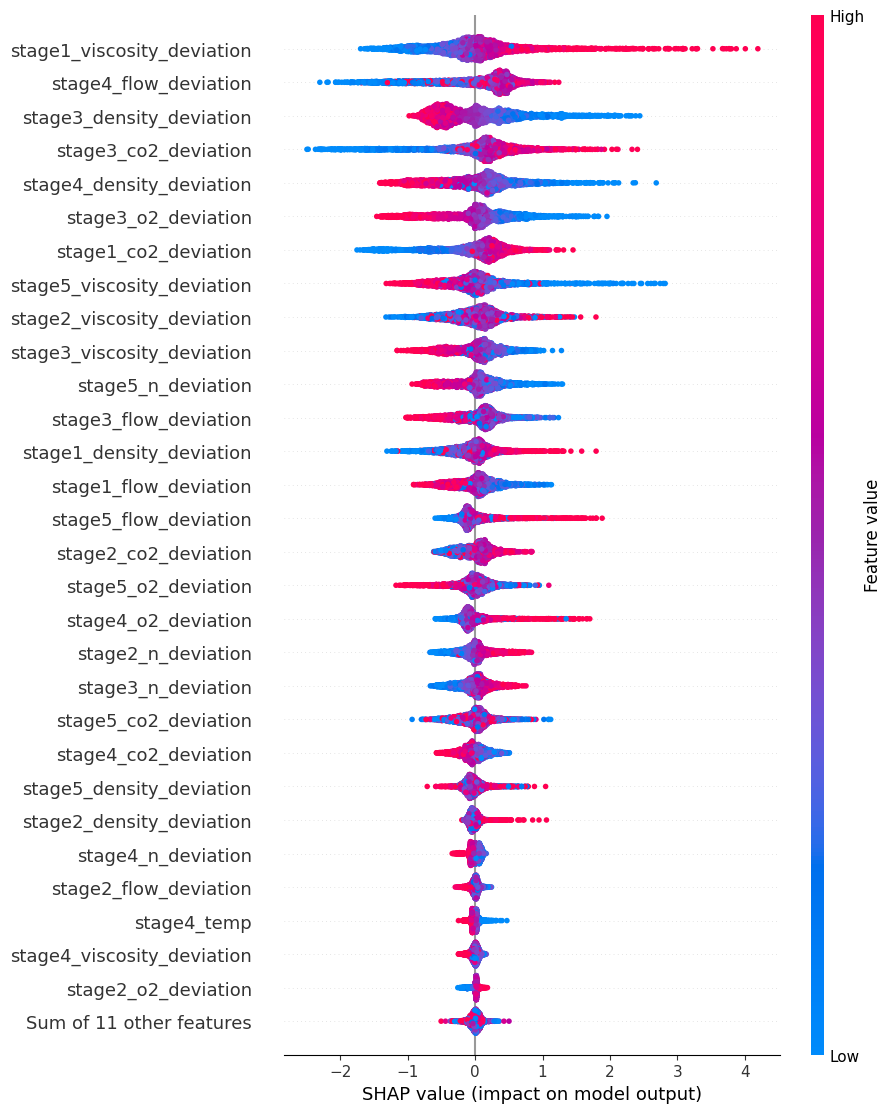

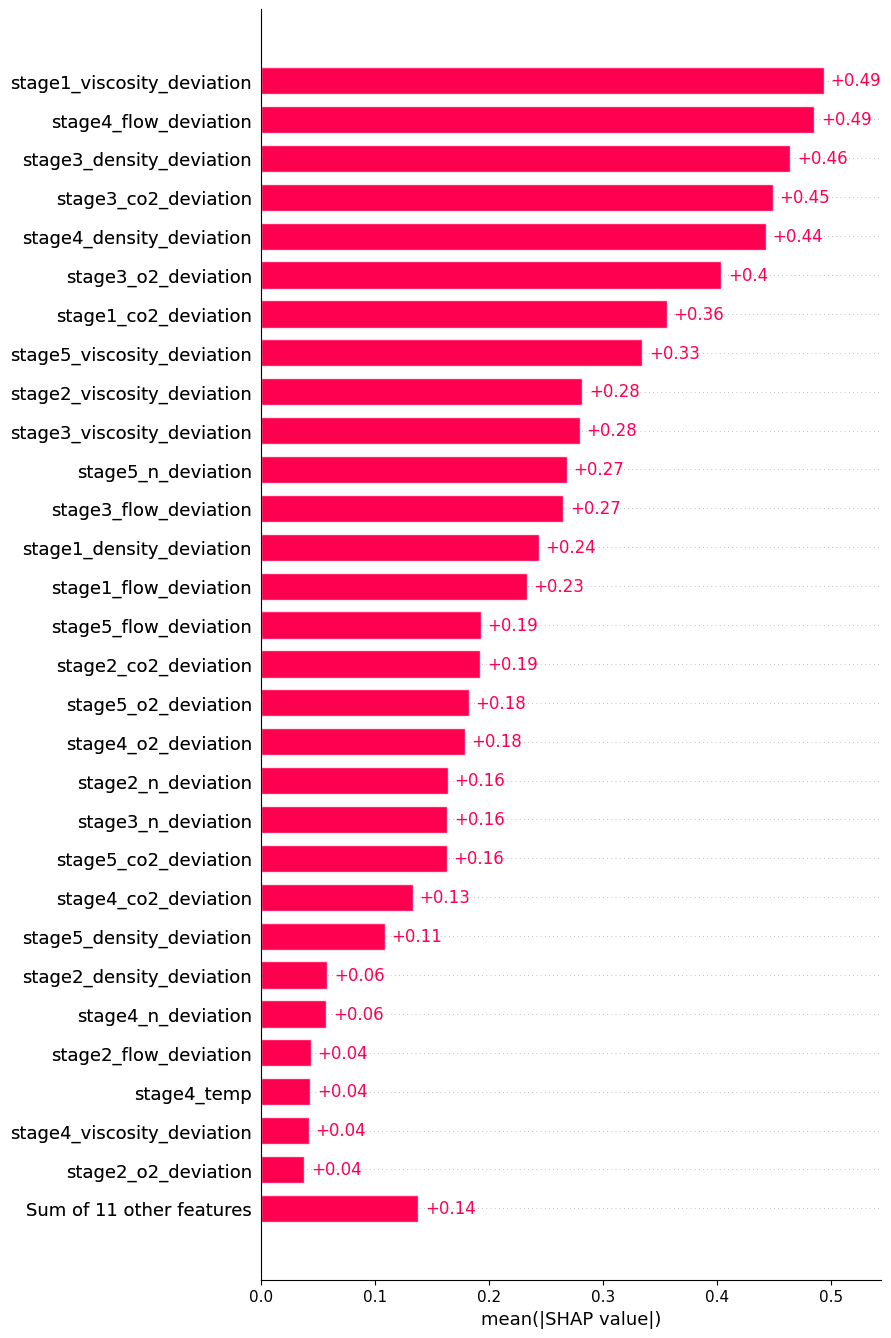

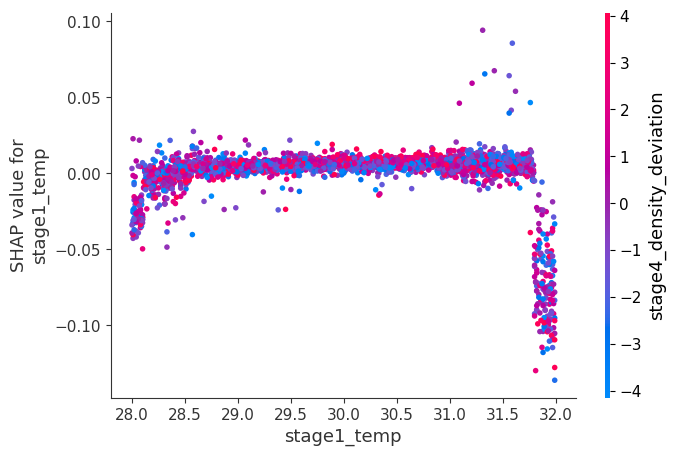

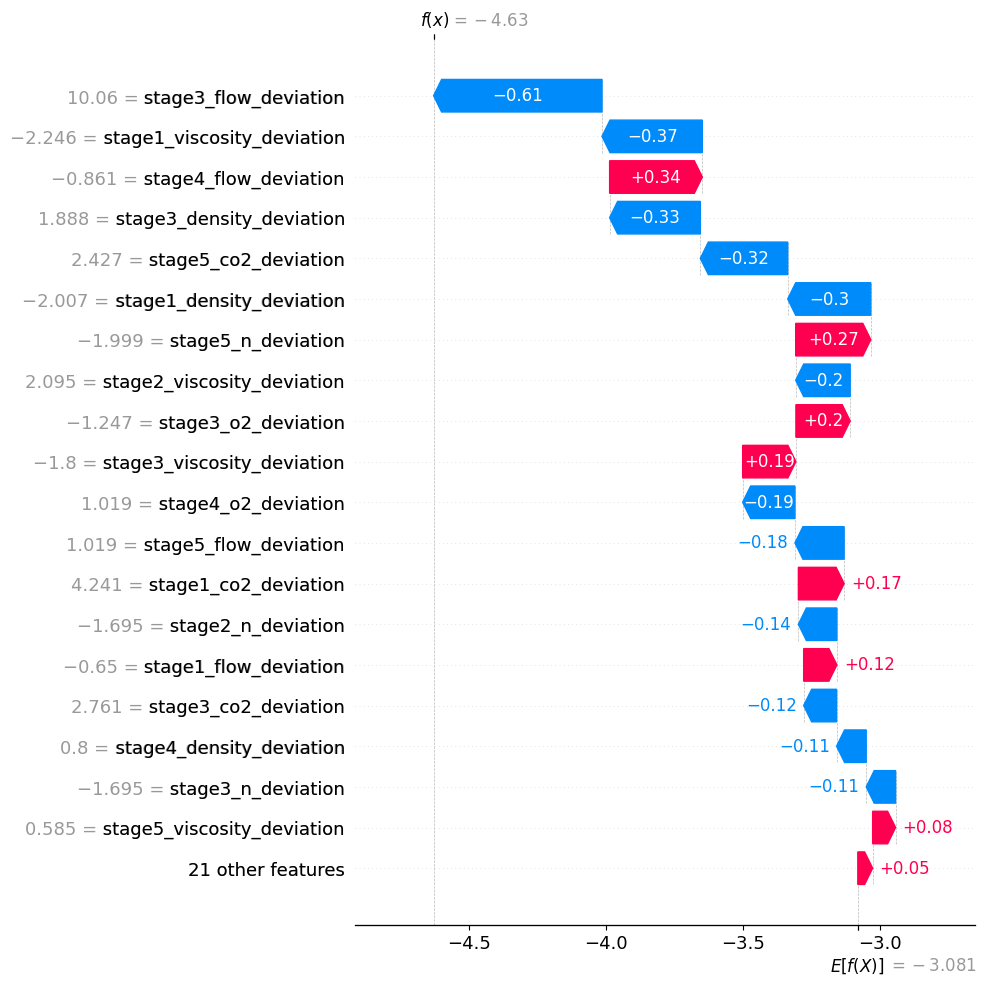

In [ ]:
from catboost import Pool
X_shap = X_test.copy()   # test 데이터

pool = Pool(X_shap)      # cat_features 없음

shap_values_full = cat_model.get_feature_importance(
    pool,
    type="ShapValues"
)

# 마지막 컬럼은 expected value
expected_value = shap_values_full[0, -1]
shap_values = shap_values_full[:, :-1]

feature_names = X_shap.columns.tolist()

expl = shap.Explanation(
    values=shap_values,
    base_values=np.full(shap_values.shape[0], expected_value),
    data=X_shap.values,
    feature_names=feature_names
)

# --------------------------------------------------
# 2️⃣ 전역 중요도
# --------------------------------------------------
shap.plots.beeswarm(expl, max_display=30)
plt.show()

shap.plots.bar(expl, max_display=30)
plt.show()

# --------------------------------------------------
# 3️⃣ 특정 변수 영향 확인
# --------------------------------------------------
target_feature = feature_names[0]  # 원하는 변수명으로 바꿔도 됨

shap.dependence_plot(
    target_feature,
    shap_values,
    X_shap,
    feature_names=feature_names
)

# --------------------------------------------------
# 4️⃣ 개별 샘플 설명
# --------------------------------------------------
idx = 0  # 보고 싶은 샘플 번호

shap.plots.waterfall(expl[idx], max_display=20)
plt.show()

shap.initjs()
shap.force_plot(
    expected_value,
    shap_values[idx],
    X_shap.iloc[idx])

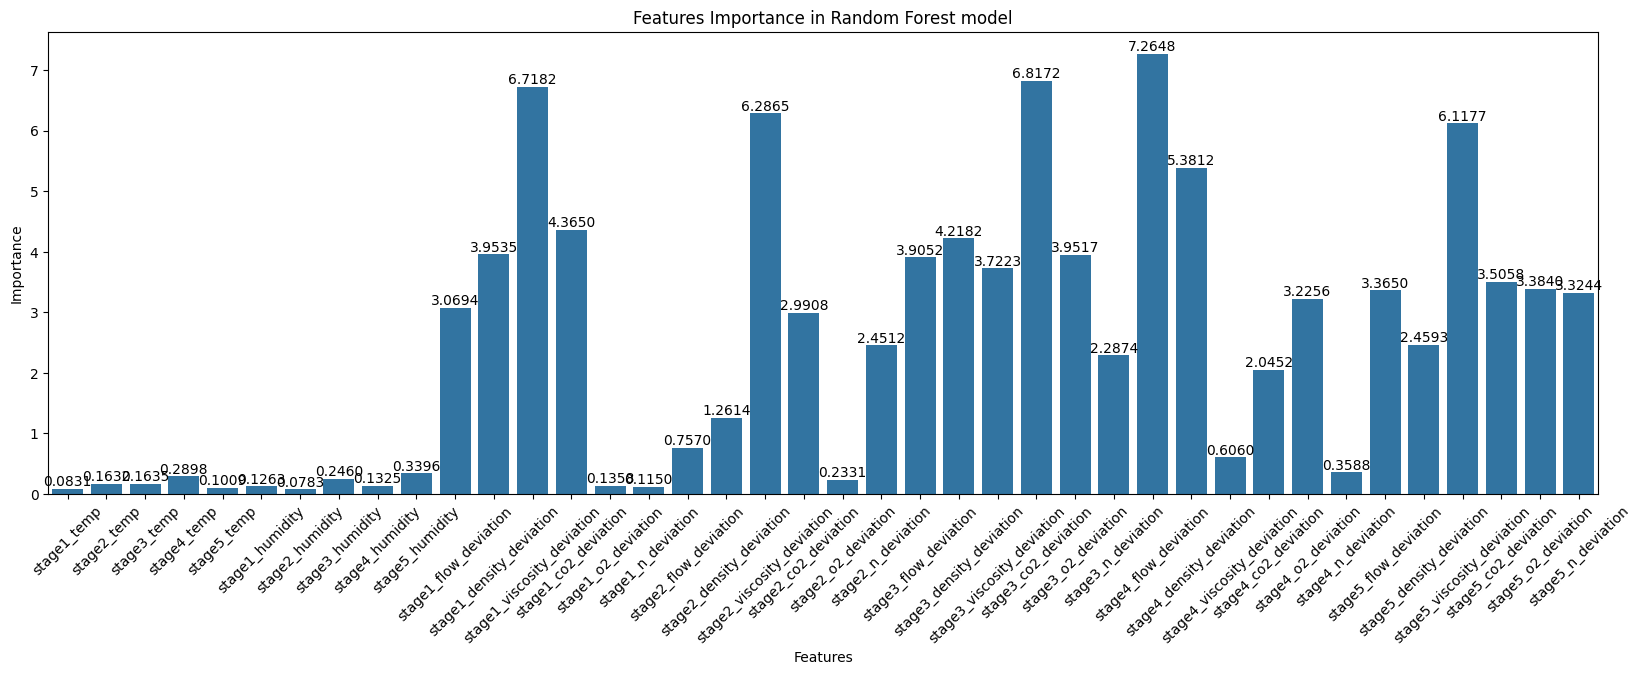

In [ ]:
#Feature Importance
fea_imp=cat_model.feature_importances_
features=cat_model.feature_names_
Importance_df={'Features':features,'Importance':fea_imp}
pd.DataFrame(Importance_df)

import seaborn as sns
plt.figure(figsize=(20,6))
ax=sns.barplot(Importance_df,x='Features',y='Importance')
ax.bar_label(ax.containers[0],fmt='%.4f')
plt.title('Features Importance in Random Forest model')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

# ----------------------------
# 0) 준비물: X, y, model_xg_O
# ----------------------------
# X: pandas.DataFrame (권장)  (컬럼명이 있어야 top feature 뽑기 쉬움)
# y: (n_samples,) 0/1 라벨
# model_xg_O: 이미 학습된 트리모델(XGBoost/LightGBM/CatBoost 등)

# 예: X = x_O (DataFrame이면 그대로, 아니면 DataFrame으로 변환)
X = df[cols[:40]]
y = df[cols[40]]   # 네 라벨 변수명에 맞게 바꿔줘

# ----------------------------
# 1) SHAP 계산 (이진분류: class=1 기준으로 통일)
# ----------------------------
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X)

# shap 출력 형태가 라이브러리/버전에 따라 다를 수 있어서 안전하게 처리
# - (n, p) 2D면 그대로
# - list면 보통 [class0, class1]
# - (n, p, 2)면 class 축이 마지막
if isinstance(shap_values, list):
    # 보통 이진분류면 shap_values[1]이 class=1
    sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
elif np.ndim(shap_values) == 3:
    # (n, p, n_classes) 형태면 class=1
    sv = shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
else:
    sv = shap_values  # (n, p)

# ----------------------------
# 2) mean(|SHAP|)로 상위 k개 컬럼 선택
# ----------------------------
k = 40  # 원하는 개수로 바꿔줘
mean_abs = np.mean(np.abs(sv), axis=0)          # (p,)
top_idx = np.argsort(mean_abs)[::-1][:k]
top_features = X.columns[top_idx].tolist()

print("Top features by mean(|SHAP|):")
for i, f in enumerate(top_features, 1):
    print(f"{i:>2}. {f}  (mean|shap|={mean_abs[X.columns.get_loc(f)]:.6f})")

X_top = X[top_features]

# ----------------------------
# 3) 로지스틱 회귀 학습/평가
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)

# 로지스틱은 스케일링 거의 필수라 파이프라인으로 묶는 게 깔끔함
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, solver="lbfgs"))  # 필요시 class_weight="balanced"
])

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]  # class=1 확률
pred = (proba >= 0.5).astype(int)

print("\nAUC:", roc_auc_score(y_test, proba))
print("ACC:", accuracy_score(y_test, pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=4))

# ----------------------------
# 4) (옵션) 로지스틱 계수 확인 (해석용)
# ----------------------------
lr = clf.named_steps["lr"]
coef = pd.Series(lr.coef_.ravel(), index=top_features).sort_values(key=np.abs, ascending=False)
print("\nTop LR coefficients (sorted by |coef|):")
print(coef.head(20))

Top features by mean(|SHAP|):
 1. stage1_viscosity_deviation  (mean|shap|=0.496314)
 2. stage4_flow_deviation  (mean|shap|=0.479448)
 3. stage3_density_deviation  (mean|shap|=0.466226)
 4. stage3_co2_deviation  (mean|shap|=0.453316)
 5. stage4_density_deviation  (mean|shap|=0.448250)
 6. stage3_o2_deviation  (mean|shap|=0.401767)
 7. stage1_co2_deviation  (mean|shap|=0.355053)
 8. stage5_viscosity_deviation  (mean|shap|=0.335326)
 9. stage2_viscosity_deviation  (mean|shap|=0.283371)
10. stage3_viscosity_deviation  (mean|shap|=0.279545)
11. stage5_n_deviation  (mean|shap|=0.264775)
12. stage3_flow_deviation  (mean|shap|=0.260408)
13. stage1_density_deviation  (mean|shap|=0.244614)
14. stage1_flow_deviation  (mean|shap|=0.236106)
15. stage5_flow_deviation  (mean|shap|=0.194573)
16. stage2_co2_deviation  (mean|shap|=0.193552)
17. stage5_o2_deviation  (mean|shap|=0.182048)
18. stage4_o2_deviation  (mean|shap|=0.181254)
19. stage5_co2_deviation  (mean|shap|=0.166544)
20. stage2_n_deviation 

In [ ]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9632    0.9926    0.9777      2713
          불량     0.9669    0.8501    0.9047       687

    accuracy                         0.9638      3400
   macro avg     0.9650    0.9214    0.9412      3400
weighted avg     0.9639    0.9638    0.9629      3400

Confusion matrix:
 [[2693   20]
 [ 103  584]]


# 오분류 데이터 분석

In [ ]:
# class 1 확률
proba_test = cat_model.predict_proba(X_test)[:, 1]

# 0/1 예측
pred_test = (proba_test >= 0.5).astype(int)

# test 데이터 복사
test_result = X_test.copy()

# 예측값만 붙이기
test_result["pred_proba_1"] = proba_test
test_result["pred_class"] = pred_test

test_result = X_test.copy()
test_result["pred_class"] = cat_model.predict(X_test)
test_result["true_label"] = y_test.values
test_result["pred_proba_1"] = proba_test
test_result

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_n_deviation,stage5_flow_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,pred_class,true_label,pred_proba_1
14695,29.78,30.63,29.81,29.36,31.07,72.19,68.25,67.13,74.27,73.51,...,-2.173228,1.018969,-1.870547,0.585448,2.427186,-2.847487,-1.999435,0,0,0.009659
14492,28.99,31.70,31.92,28.56,29.76,75.91,67.21,75.07,73.03,71.33,...,-1.002007,-1.213819,4.441331,4.779001,-1.723100,1.771311,0.980936,0,0,0.007956
1509,28.09,28.53,28.47,31.11,31.99,77.43,69.55,72.46,71.12,76.79,...,0.353033,-2.382825,-1.687764,1.527814,-3.657651,2.374970,2.572159,0,0,0.016570
5232,28.16,29.74,30.52,29.98,29.77,72.40,69.92,72.17,78.84,72.65,...,-1.420363,-1.454755,0.288102,1.516247,0.756031,2.143028,-1.105868,1,1,0.565293
16588,30.83,31.90,31.62,28.30,31.18,76.79,73.17,68.83,72.89,77.46,...,-0.805535,-4.083647,-6.431336,2.508460,-2.275242,-1.653430,-1.797993,0,0,0.000752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3153,31.48,31.75,31.98,28.56,31.63,72.24,71.28,74.67,75.17,67.69,...,0.141134,-1.526567,2.210748,-0.679083,-7.892881,1.856105,-0.244853,0,0,0.001318
4641,29.43,30.61,31.99,29.71,31.70,77.81,75.72,77.17,73.95,72.53,...,0.143112,-1.117983,-4.892056,-0.594501,-1.279386,2.539102,1.370608,1,1,0.948903
10129,29.06,31.77,29.84,31.84,31.70,72.02,68.42,76.89,67.70,72.91,...,0.013165,-1.924961,6.950068,2.655120,-6.611964,-0.119839,3.362833,0,0,0.002012
7560,29.07,31.78,30.57,31.11,29.41,72.36,68.34,71.35,69.91,69.14,...,2.642686,-3.693125,2.151747,5.344171,-1.589990,2.487419,-3.588456,0,0,0.058709


In [ ]:
test_result_F0=test_result[(test_result['true_label']==0 )& (test_result['pred_class']!=0)]
test_result_T0=test_result[(test_result['true_label']==0 )& (test_result['pred_class']==0)]
test_result_F1=test_result[(test_result['true_label']==1)&( test_result['pred_class']!=1)]
test_result_T1=test_result[(test_result['true_label']==1)&( test_result['pred_class']==1)]
test_result_0=test_result[(test_result['true_label']==0 )]
test_result_1=test_result[(test_result['true_label']==1)]
test_result_F1["pred_proba_1"].describe()

count    103.000000
mean       0.247197
std        0.157280
min        0.000222
25%        0.115204
50%        0.265117
75%        0.372236
max        0.499878
Name: pred_proba_1, dtype: float64

In [ ]:
df_fn_low = test_result_F1[test_result_F1["pred_proba_1"] < 0.2]
import numpy as np

fn_idx = df_fn_low.index
tp_idx = test_result_T1.index

mean_shap_fn = np.mean(shap_values[fn_idx], axis=0)
mean_shap_tp = np.mean(shap_values[tp_idx], axis=0)

diff = np.abs(mean_shap_fn - mean_shap_tp)
diff

array([8.60805763e-04, 2.93390237e-03, 2.19629788e-04, 1.05970392e-02,
       2.78761374e-03, 8.68454177e-04, 2.19166456e-03, 4.79381812e-03,
       3.66686556e-05, 3.98511667e-03, 1.57815597e-01, 3.05176570e-01,
       3.98844848e-01, 1.55428305e-01, 4.66812132e-03, 3.91888537e-04,
       4.68806982e-02, 5.51665885e-02, 2.56078299e-01, 1.18266650e-01,
       1.03646342e-02, 2.38883034e-01, 3.60047811e-01, 5.54807666e-01,
       1.75609331e-01, 4.96897782e-01, 3.59752271e-01, 2.24102926e-01,
       3.82569551e-01, 3.43911821e-01, 3.24178617e-02, 1.33142060e-01,
       2.95182373e-01, 4.65161935e-04, 3.08832404e-01, 1.20131503e-01,
       4.79408322e-01, 2.02754319e-01, 2.28497968e-01, 4.73752637e-02])

In [ ]:
result_df = pd.DataFrame({
    "feature": X.columns,
    "TP_mean_shap": mean_shap_tp,
    "FN_mean_shap": mean_shap_fn,
    "difference(TP-FN)": diff,
    "abs_difference": np.abs(diff)
})

# 차이 큰 순서 정렬
result_df = result_df.sort_values("abs_difference", ascending=False)

result_df.head(15)

,feature,TP_mean_shap,FN_mean_shap,difference(TP-FN),abs_difference
23,stage3_density_deviation,0.485772,-0.069036,0.554808,0.554808
25,stage3_co2_deviation,0.505890,0.008992,0.496898,0.496898
36,stage5_viscosity_deviation,0.380297,-0.099111,0.479408,0.479408
12,stage1_viscosity_deviation,0.523623,0.124778,0.398845,0.398845
28,stage4_flow_deviation,0.434222,0.051652,0.382570,0.382570
22,stage3_flow_deviation,0.331828,-0.028219,0.360048,0.360048
26,stage3_o2_deviation,0.320488,-0.039264,0.359752,0.359752
29,stage4_density_deviation,0.370673,0.026761,0.343912,0.343912
34,stage5_flow_deviation,0.304676,-0.004156,0.308832,0.308832
11,stage1_density_deviation,0.199992,-0.105184,0.305177,0.305177


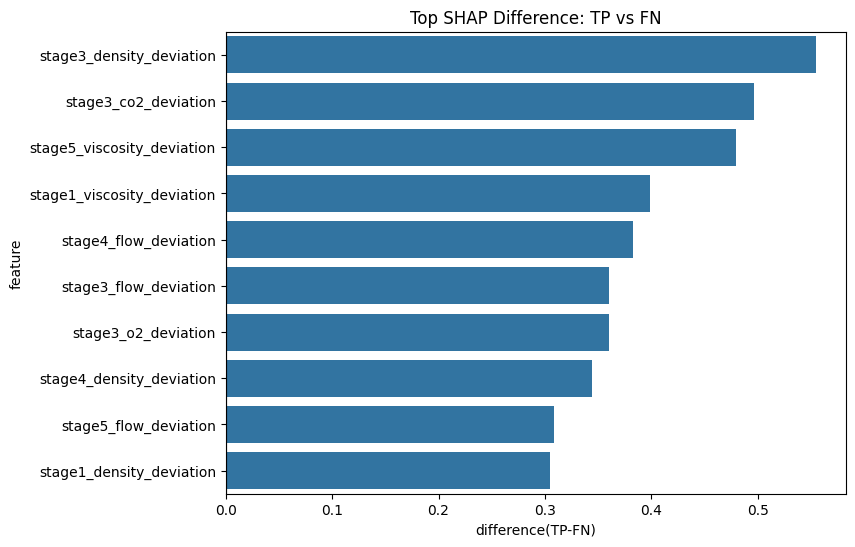

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top = result_df.head(10)

plt.figure(figsize=(8,6))
sns.barplot(x="difference(TP-FN)", y="feature", data=top)
plt.title("Top SHAP Difference: TP vs FN")
plt.axvline(0, color="black")
plt.show()

불량(1)을 정상이라고 오분류 하는데 크게 기여한 top 변수들

In [ ]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

results = []
feature_list = df[cols[:40]]
for col in feature_list:   # feature_list = 분석할 변수 리스트
    tp = test_result_T1[col]
    fn = test_result_F1[col]

    stat, p = mannwhitneyu(tp, fn, alternative="two-sided")

    results.append({
        "feature": col,
        "TP_median": tp.median(),
        "FN_median": fn.median(),
        "median_diff(TP-FN)": tp.median() - fn.median(),
        "p_value": p
    })

result_df = pd.DataFrame(results)
result_df = result_df.sort_values("p_value")

result_df.head(15)

,feature,TP_median,FN_median,median_diff(TP-FN),p_value
23,stage3_density_deviation,-1.141326,0.288110,-1.429436,3.059097e-08
22,stage3_flow_deviation,-1.266431,2.078385,-3.344816,5.648523e-06
31,stage4_co2_deviation,-1.781815,1.893236,-3.675052,3.715336e-05
26,stage3_o2_deviation,-1.097585,-0.001430,-1.096155,5.558528e-05
38,stage5_o2_deviation,-0.134252,0.986311,-1.120563,7.520423e-05
27,stage3_n_deviation,0.147878,-0.748629,0.896507,2.744915e-04
21,stage2_n_deviation,0.147878,-0.748629,0.896507,2.744915e-04
36,stage5_viscosity_deviation,0.289317,0.923917,-0.634600,6.459368e-04
28,stage4_flow_deviation,0.878236,0.241082,0.637154,1.106853e-03
32,stage4_o2_deviation,0.277552,-0.512948,0.790499,3.630374e-03


C:\Users\jsuai\AppData\Local\Temp\ipykernel_20532\489482071.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.swarmplot(data=test_result, x='true_label', y='stage3_flow_deviation', hue='pred_class',color='red', alpha=0.7)
c:\python\Python39\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\R

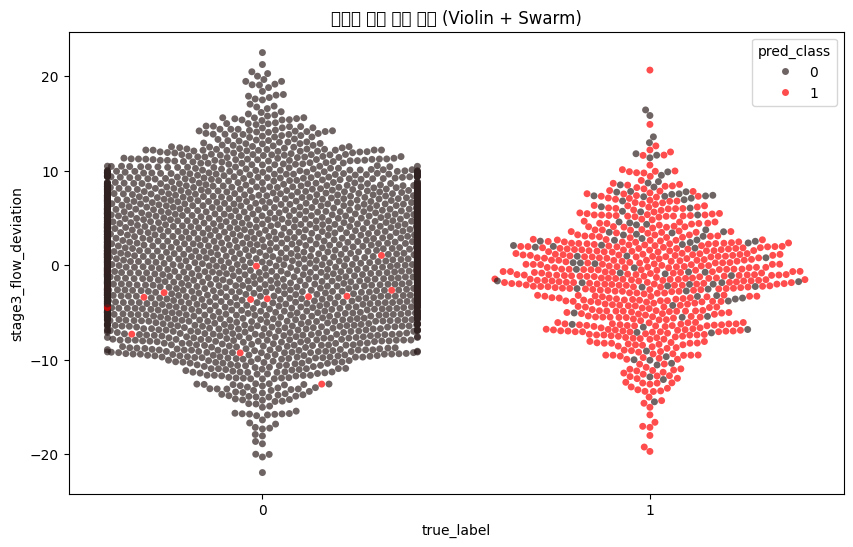

In [ ]:
plt.figure(figsize=(10, 6))

# 2. 그 위에 스웜 플롯으로 실제 데이터를 찍음
sns.swarmplot(data=test_result, x='true_label', y='stage3_flow_deviation', hue='pred_class',color='red', alpha=0.7)

plt.title("요일별 결제 금액 분포 (Violin + Swarm)")
plt.show()

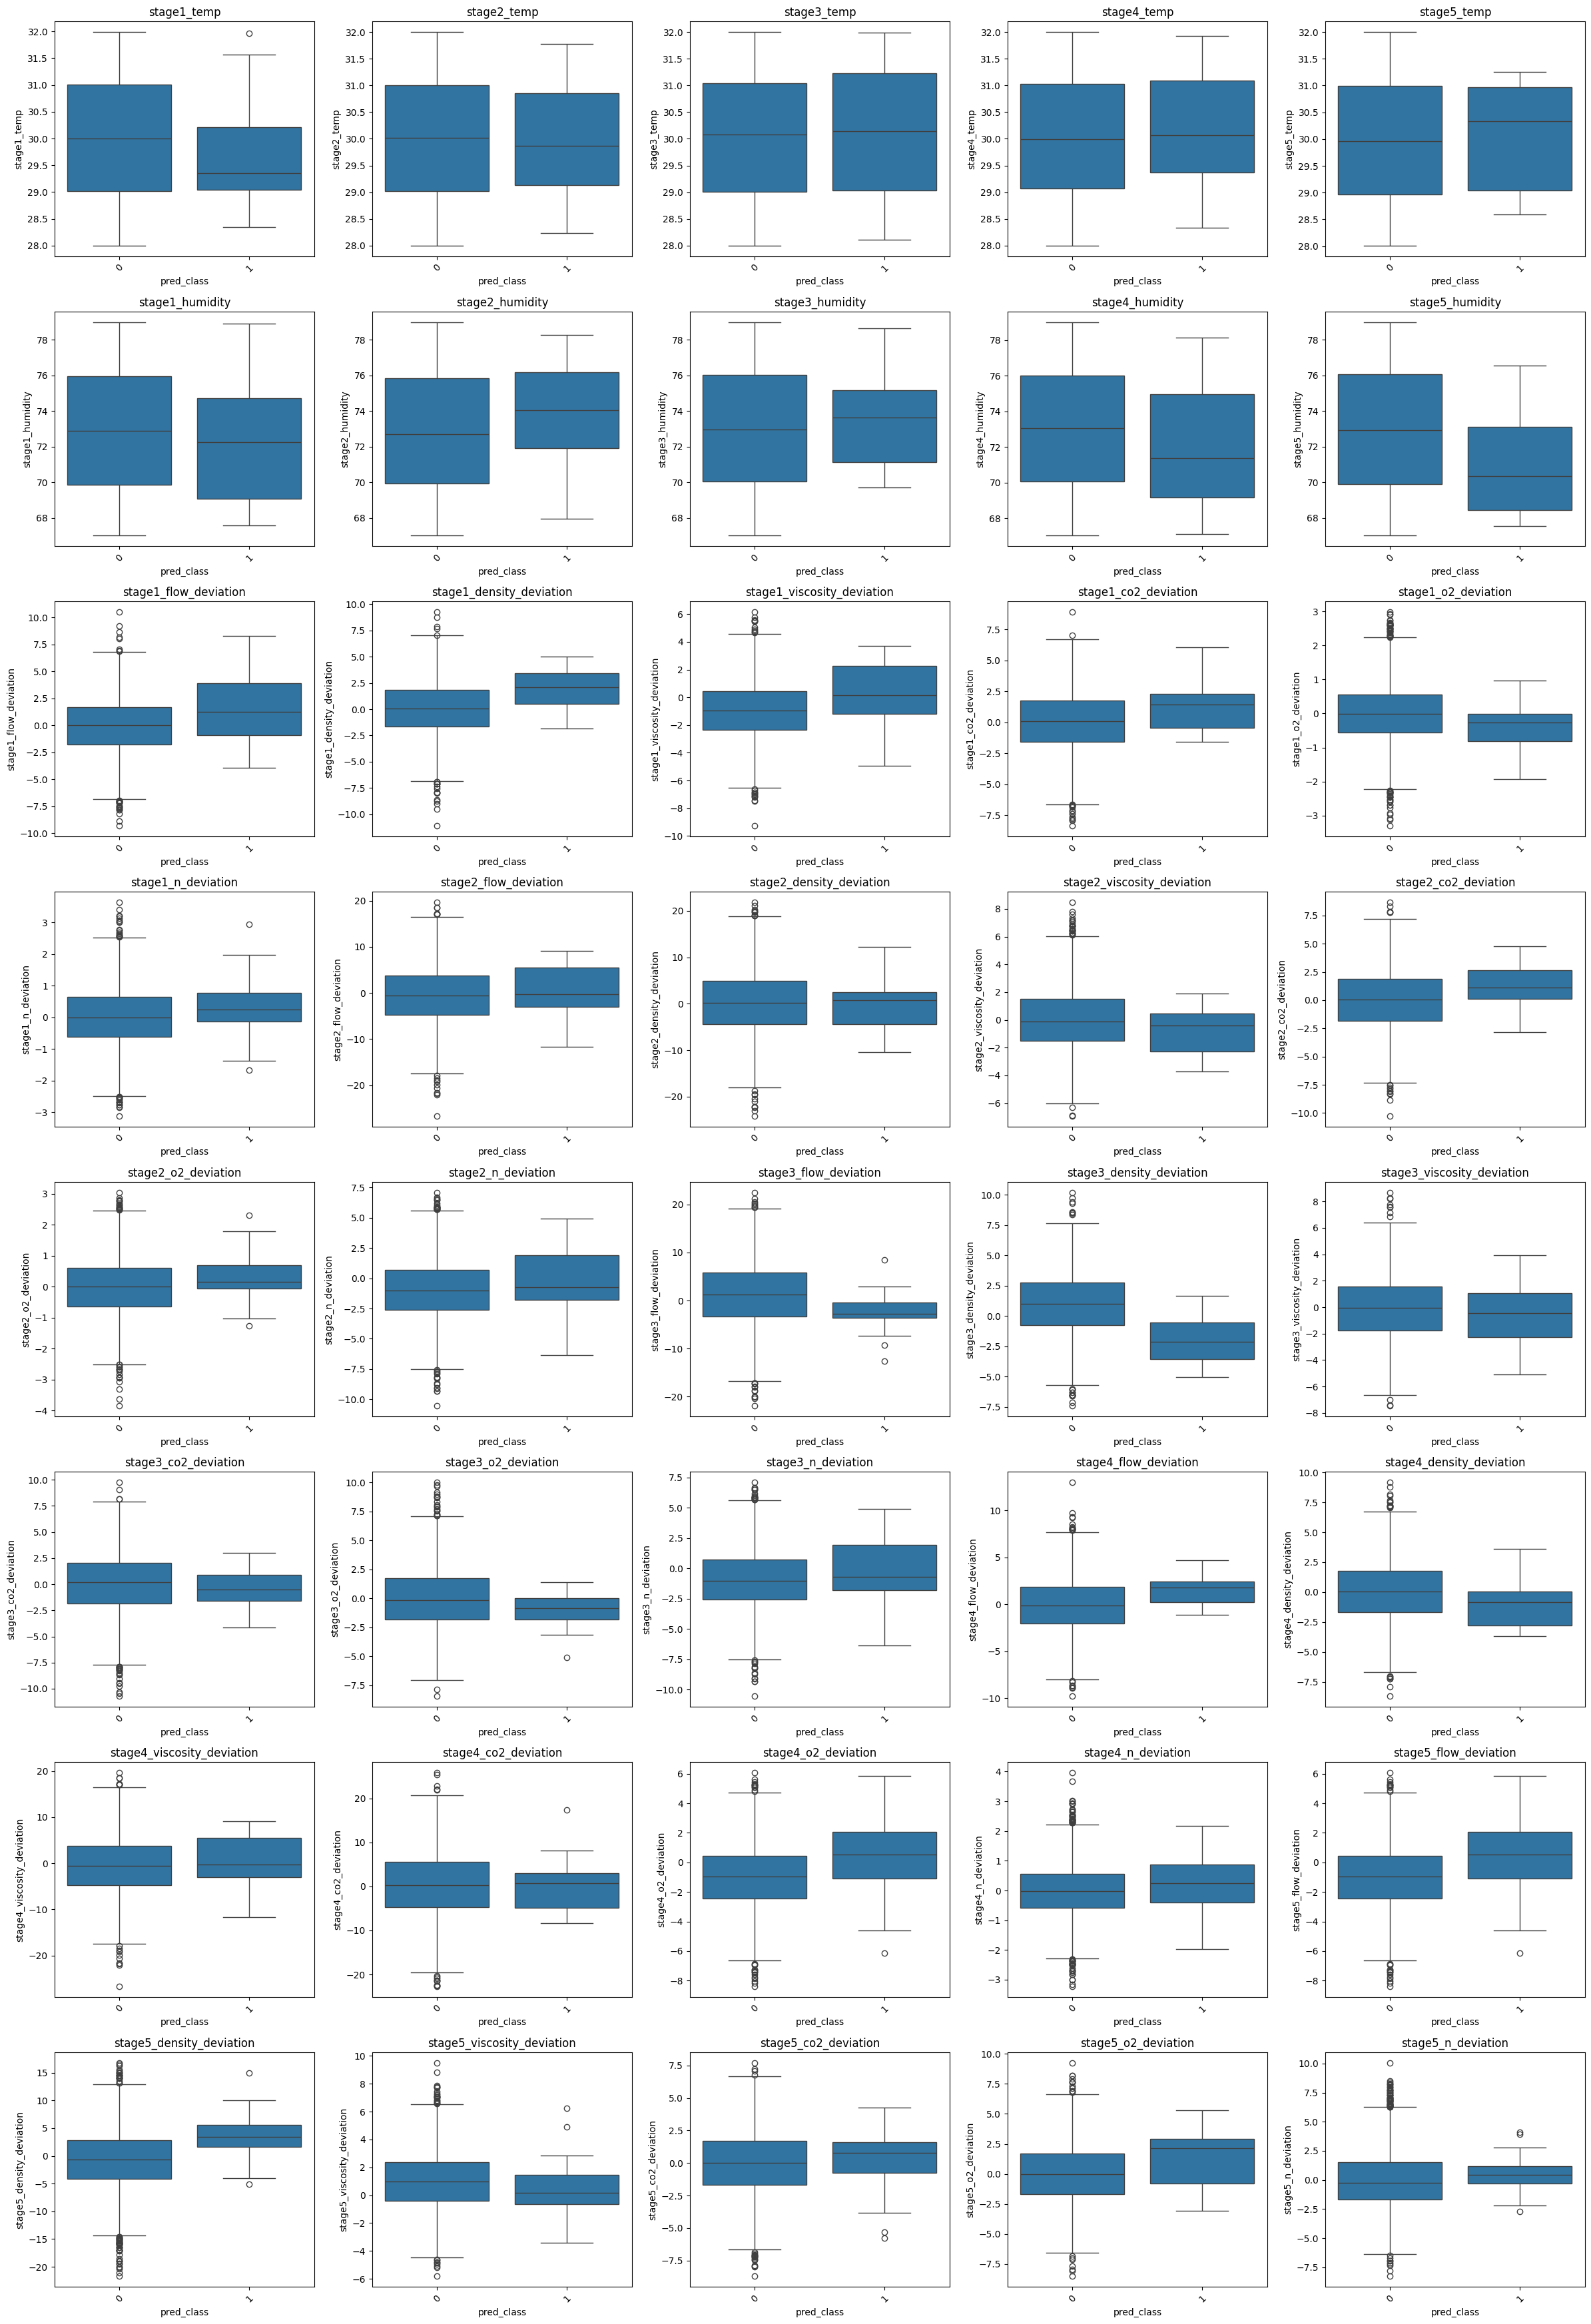

In [ ]:
features = test_result_0.columns[:-2]

fig, axes = plt.subplots(8, 5, figsize=(24, 35))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='pred_class', y=col, data=test_result_0, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

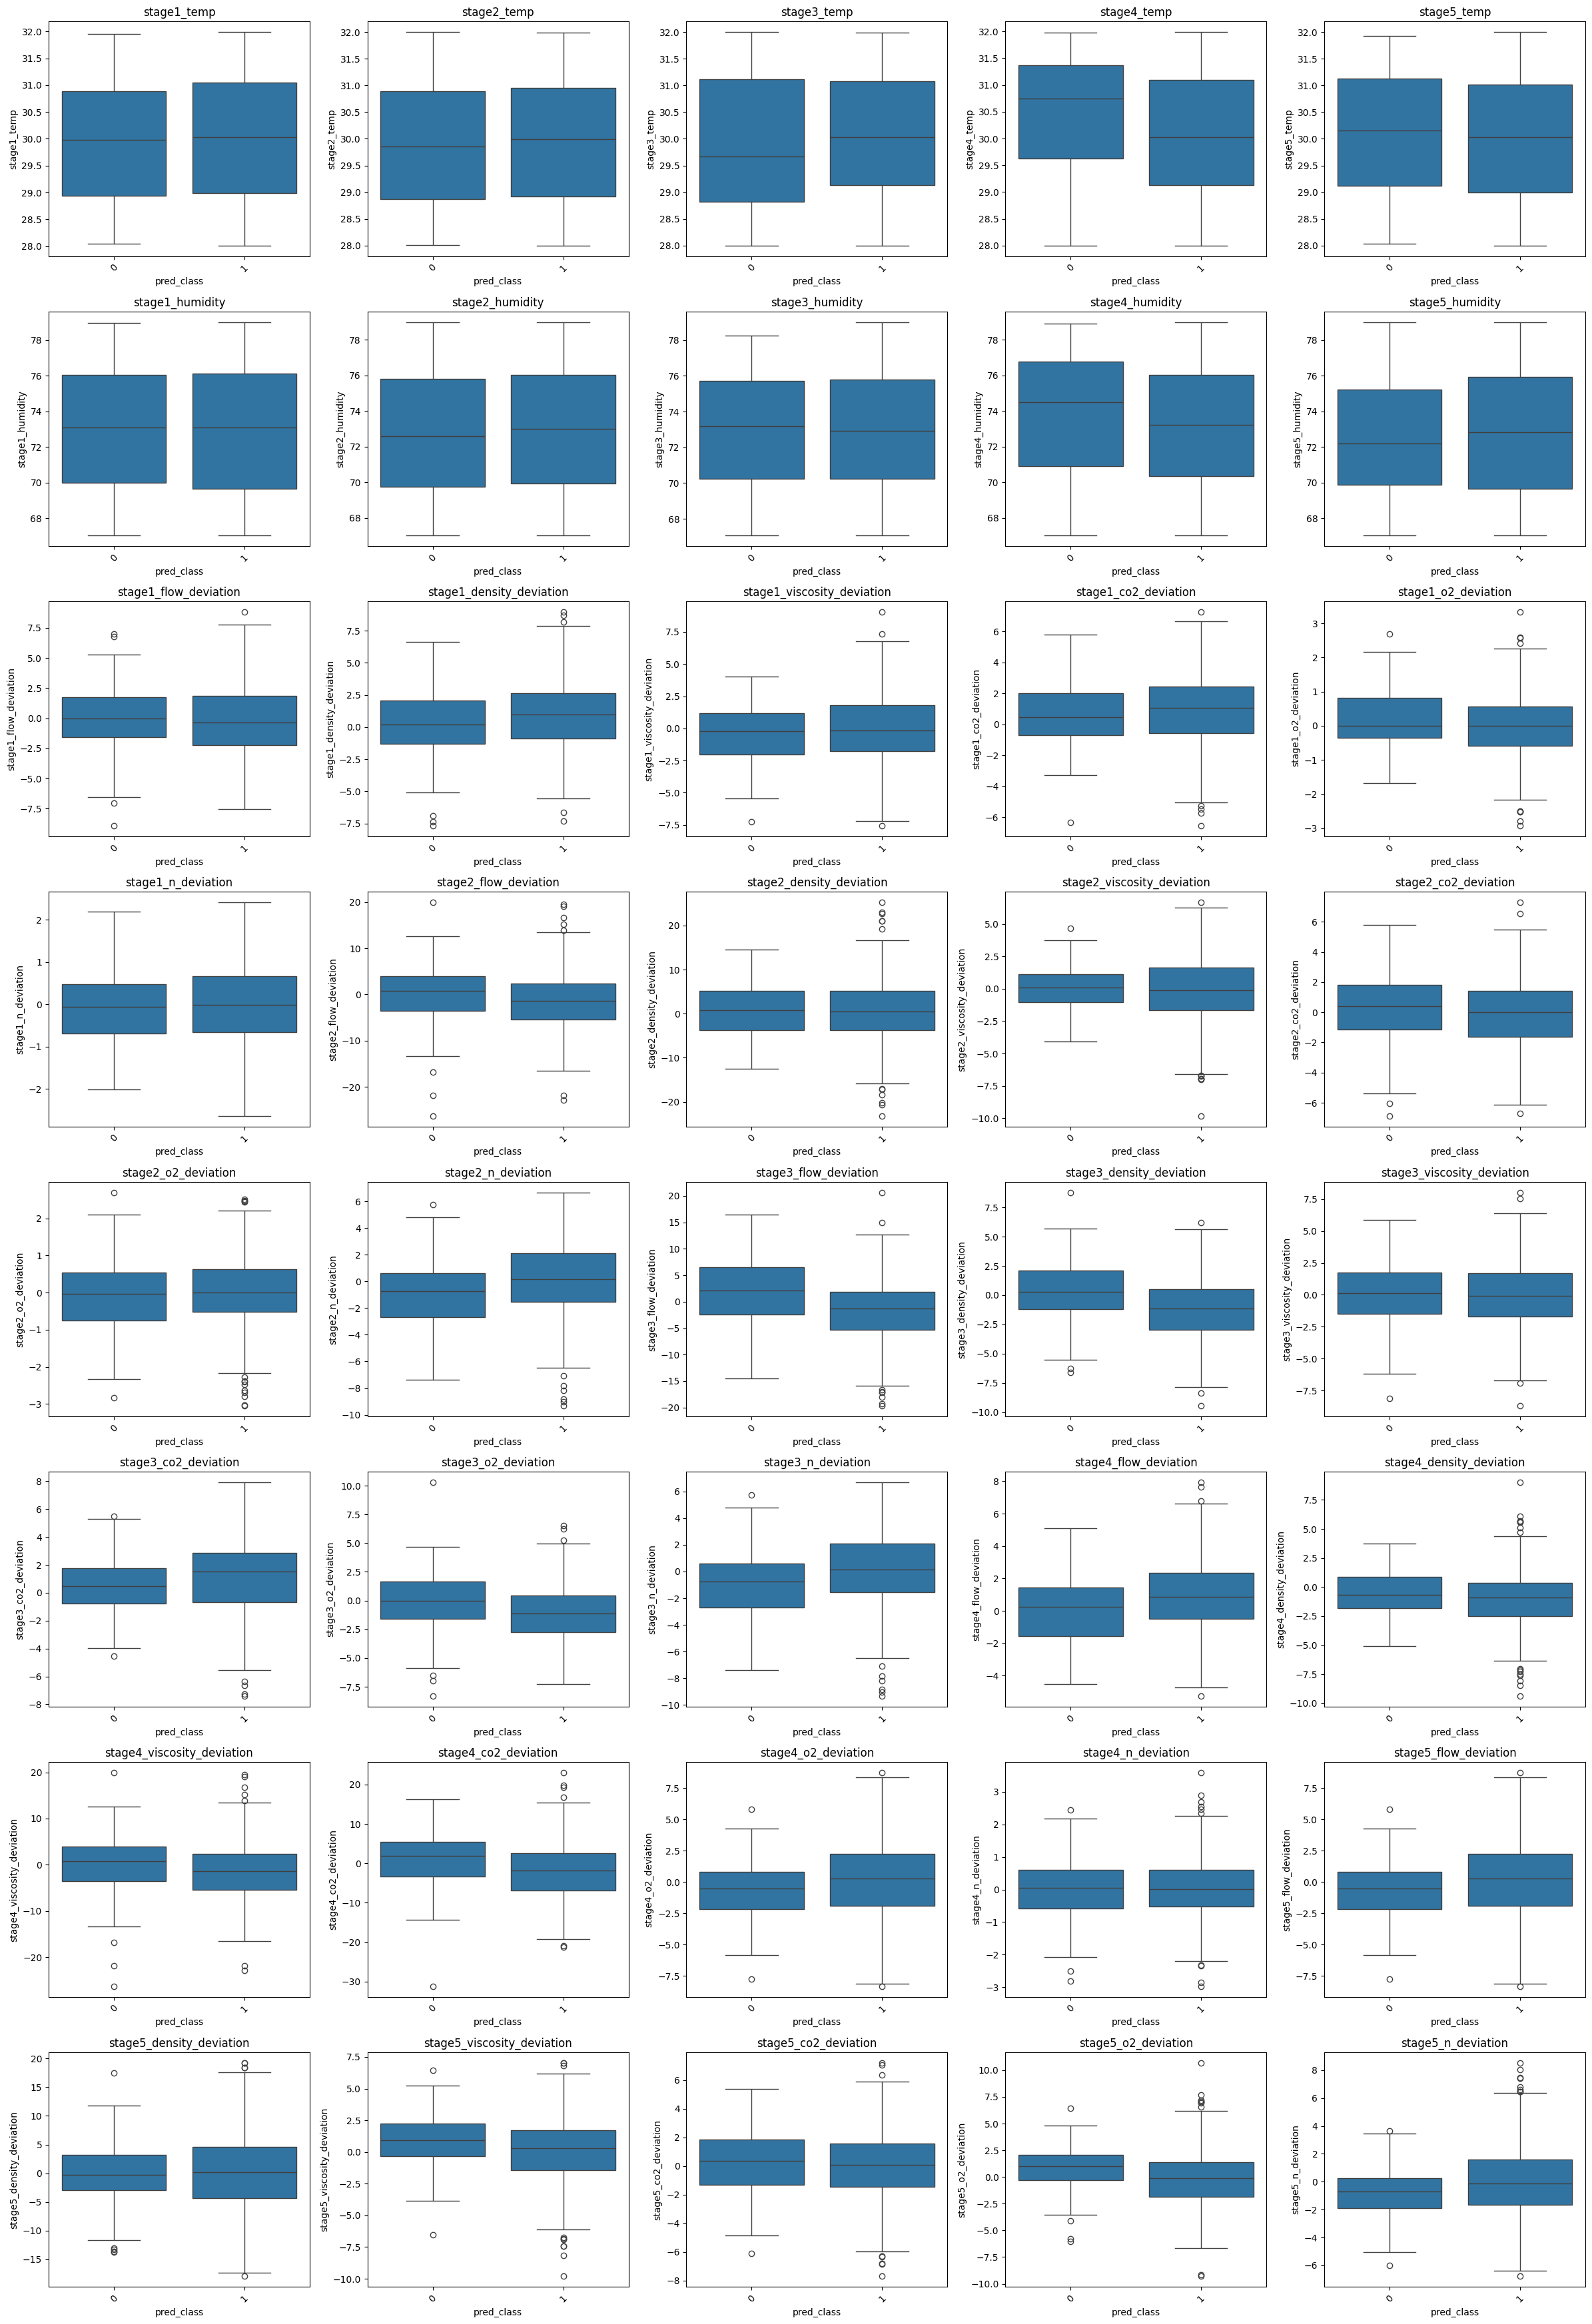

In [ ]:
features = test_result_1.columns[:-2]

fig, axes = plt.subplots(8, 5, figsize=(24, 35))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='pred_class', y=col, data=test_result_1, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# stage 별 모델링

In [ ]:
df_stage=df.copy()
df_stage=df_stage.sort_index(axis=1)
df_stage
cols=df_stage.columns
df_stage


,label,stage1_co2_deviation,stage1_density_deviation,stage1_flow_deviation,stage1_humidity,stage1_n_deviation,stage1_o2_deviation,stage1_temp,stage1_viscosity_deviation,stage2_co2_deviation,...,stage4_temp,stage4_viscosity_deviation,stage5_co2_deviation,stage5_density_deviation,stage5_flow_deviation,stage5_humidity,stage5_n_deviation,stage5_o2_deviation,stage5_temp,stage5_viscosity_deviation
0,1,2.885678,3.217163,0.727501,69.08,-0.229145,-1.830675,28.57,5.716122,1.292311,...,30.91,3.897850,2.249968,14.642069,-0.914915,69.41,1.574354,0.823538,31.62,-1.124235
1,1,4.170145,2.899058,2.168080,68.24,-0.678211,0.179070,31.74,0.838872,1.265400,...,29.52,-0.336600,3.381750,12.361204,-4.937284,76.11,-0.056206,5.827666,30.70,3.886517
2,0,1.783114,2.700569,3.753856,67.98,-0.649136,1.001300,31.25,1.686915,-0.742775,...,30.74,5.108084,-0.052572,1.587669,-0.955908,70.73,-2.745544,-0.597566,30.26,1.665659
3,0,3.879756,0.326173,-4.743517,68.60,-0.809781,0.743327,29.96,1.359592,-0.002497,...,31.96,-2.535448,3.230979,4.550075,-2.134062,76.71,0.157905,-0.032255,31.12,0.020477
4,0,-0.741553,4.694635,-2.484233,78.24,-0.729316,-0.027711,30.09,0.452394,0.855256,...,30.46,-10.559326,-0.516248,9.741397,-0.192612,74.76,0.020616,2.129390,28.84,0.979056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16993,0,3.740531,-0.362146,-2.795190,77.29,0.553653,-0.854161,29.68,-0.811106,3.598268,...,30.78,2.143183,2.343462,-1.251171,-1.627189,73.09,1.252295,-0.342200,28.06,-0.972060
16994,1,1.700858,0.814505,-1.342667,76.02,-0.656151,0.114318,30.24,0.871520,-1.172652,...,28.94,-1.132321,-1.108650,5.861357,2.228396,69.52,1.744824,-0.813562,29.23,0.414884
16995,0,-2.013709,3.188329,0.482725,72.11,0.001379,1.976959,28.44,-0.615150,-1.124725,...,30.57,-3.958995,0.000299,-0.722216,-0.859033,68.72,-1.652202,1.684467,28.79,4.351513
16996,0,-0.645750,1.092366,0.961052,75.93,-0.637596,0.010440,28.17,-2.545665,1.127027,...,28.99,-5.690331,-2.000998,-5.930715,-2.373612,76.70,-0.552398,4.125043,29.71,1.433596


In [ ]:

X = df_stage[cols[1:9]]
y = df_stage['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.8296    0.9657    0.8925      2713
          불량     0.6157    0.2169    0.3208       687

    accuracy                         0.8144      3400
   macro avg     0.7227    0.5913    0.6066      3400
weighted avg     0.7864    0.8144    0.7770      3400

Confusion matrix:
 [[2620   93]
 [ 538  149]]


In [ ]:
X = df_stage[cols[9:17]]
y = df_stage['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.8181    0.9783    0.8911      2713
          불량     0.6218    0.1412    0.2301       687

    accuracy                         0.8091      3400
   macro avg     0.7200    0.5597    0.5606      3400
weighted avg     0.7785    0.8091    0.7575      3400

Confusion matrix:
 [[2654   59]
 [ 590   97]]


In [ ]:
X = df_stage[cols[17:25]]
y = df_stage['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.8596    0.9595    0.9068      2713
          불량     0.7043    0.3814    0.4948       687

    accuracy                         0.8426      3400
   macro avg     0.7820    0.6704    0.7008      3400
weighted avg     0.8283    0.8426    0.8236      3400

Confusion matrix:
 [[2603  110]
 [ 425  262]]


In [ ]:
X = df_stage[cols[25:33]]
y = df_stage['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.8519    0.9646    0.9048      2713
          불량     0.7073    0.3377    0.4571       687

    accuracy                         0.8379      3400
   macro avg     0.7796    0.6512    0.6809      3400
weighted avg     0.8227    0.8379    0.8143      3400

Confusion matrix:
 [[2617   96]
 [ 455  232]]


In [ ]:
X = df_stage[cols[33:]]
y = df_stage['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.8533    0.9735    0.9094      2713
          불량     0.7639    0.3392    0.4698       687

    accuracy                         0.8453      3400
   macro avg     0.8086    0.6563    0.6896      3400
weighted avg     0.8353    0.8453    0.8206      3400

Confusion matrix:
 [[2641   72]
 [ 454  233]]


In [ ]:
X = df_stage[cols[17:]]
y = df_stage['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9479    0.9860    0.9666      2713
          불량     0.9343    0.7860    0.8538       687

    accuracy                         0.9456      3400
   macro avg     0.9411    0.8860    0.9102      3400
weighted avg     0.9452    0.9456    0.9438      3400

Confusion matrix:
 [[2675   38]
 [ 147  540]]


In [ ]:
X = df_stage[cols[17:33]]
y = df_stage['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9235    0.9738    0.9480      2713
          불량     0.8683    0.6812    0.7635       687

    accuracy                         0.9147      3400
   macro avg     0.8959    0.8275    0.8557      3400
weighted avg     0.9123    0.9147    0.9107      3400

Confusion matrix:
 [[2642   71]
 [ 219  468]]
